In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import pandas as pd
from sklearn.datasets import load_linnerud

data = load_linnerud()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.DataFrame(data.target, columns=data.target_names)

print(X.head())
print(y.head())

print(X.shape)
print(y.shape)

   Chins  Situps  Jumps
0    5.0   162.0   60.0
1    2.0   110.0   60.0
2   12.0   101.0  101.0
3   12.0   105.0   37.0
4   13.0   155.0   58.0
   Weight  Waist  Pulse
0   191.0   36.0   50.0
1   189.0   37.0   52.0
2   193.0   38.0   58.0
3   162.0   35.0   62.0
4   189.0   35.0   46.0
(20, 3)
(20, 3)


In [2]:
print(X.info())
print(X.describe())

print(y.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Chins   20 non-null     float64
 1   Situps  20 non-null     float64
 2   Jumps   20 non-null     float64
dtypes: float64(3)
memory usage: 612.0 bytes
None
           Chins      Situps      Jumps
count  20.000000   20.000000   20.00000
mean    9.450000  145.550000   70.30000
std     5.286278   62.566575   51.27747
min     1.000000   50.000000   25.00000
25%     4.750000  101.000000   39.50000
50%    11.500000  122.500000   54.00000
75%    13.250000  210.000000   85.25000
max    17.000000  251.000000  250.00000
           Weight      Waist      Pulse
count   20.000000  20.000000  20.000000
mean   178.600000  35.400000  56.100000
std     24.690505   3.201973   7.210373
min    138.000000  31.000000  46.000000
25%    160.750000  33.000000  51.500000
50%    176.000000  35.000000  55.000000
75%    191.500000  37.0

In [3]:
print(X.isnull().sum())
print(y.isnull().sum())

Chins     0
Situps    0
Jumps     0
dtype: int64
Weight    0
Waist     0
Pulse     0
dtype: int64


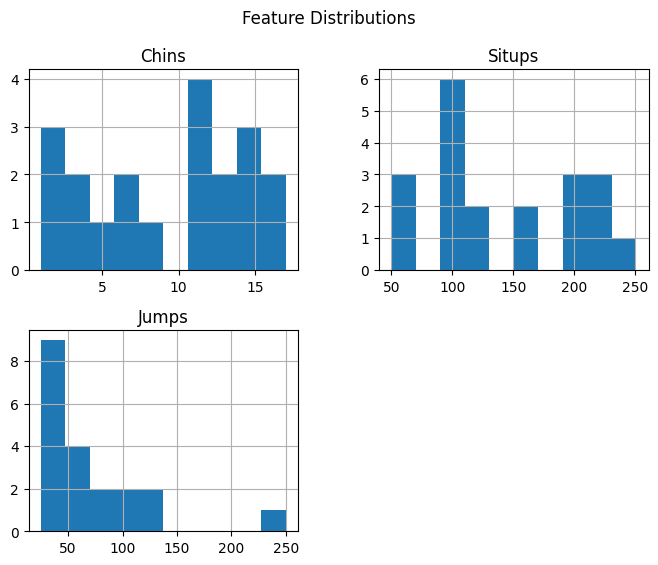

In [6]:
X.hist(figsize=(8,6))
plt.suptitle("Feature Distributions")
plt.show()

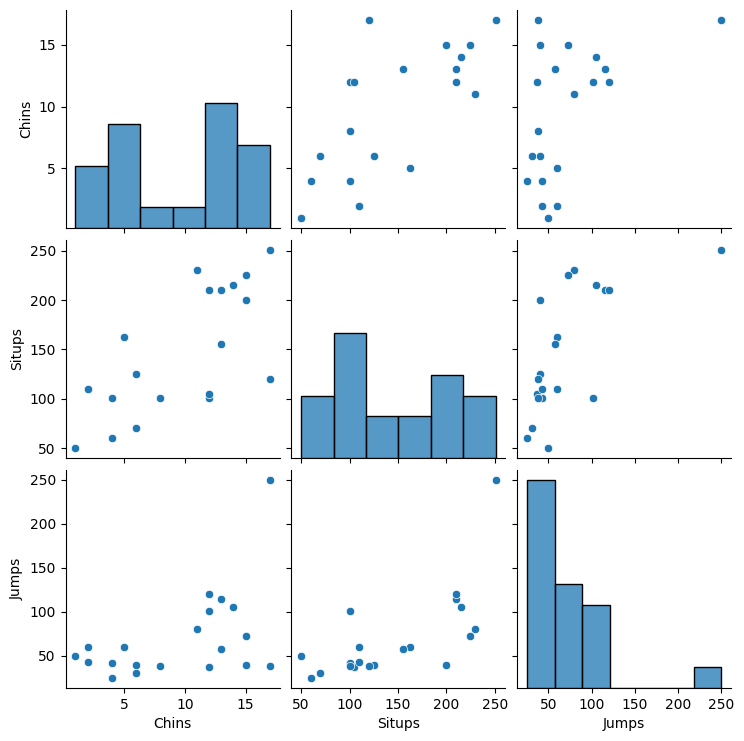

In [7]:
sns.pairplot(X)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [10]:
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 242.75831666666667
R2 Score: -1.055518633988381


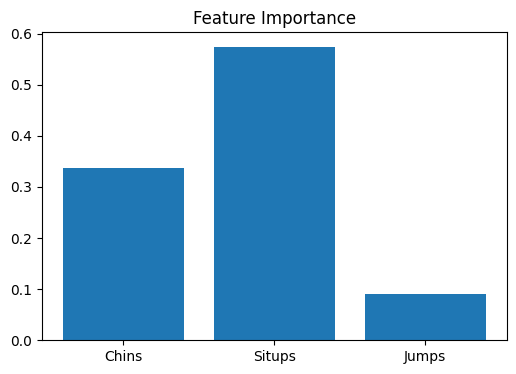

In [12]:
import numpy as np

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(6,4))
plt.bar(features, importances)
plt.title("Feature Importance")
plt.show()

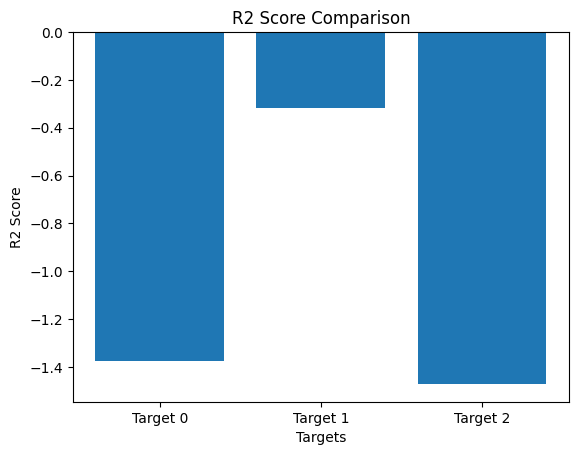

In [19]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# R2 for each target
r2_0 = r2_score(y_test.iloc[:,0], y_pred[:,0])
r2_1 = r2_score(y_test.iloc[:,1], y_pred[:,1])
r2_2 = r2_score(y_test.iloc[:,2], y_pred[:,2])


# Plot
plt.bar(['Target 0','Target 1','Target 2'], [r2_0, r2_1, r2_2])
plt.xlabel("Targets")
plt.ylabel("R2 Score")
plt.title("R2 Score Comparison")
plt.show()

The model didn’t perform well, as shown by the negative R² score, which means its predictions are even worse than just predicting the average value. One main reason is that the dataset is very small, so the model doesn’t get enough data to learn properly. Also, this is a multi-output regression problem, and not all targets have a strong relationship with the input features, which makes prediction harder. Because of these reasons, the model is not able to generalize well on the test data.